<a href="https://colab.research.google.com/github/yalindi/2425568_ml/blob/main/2425568.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [105]:
!git clone https://github.com/yalindi/2425568_ml.git

fatal: destination path '2425568_ml' already exists and is not an empty directory.


##**Import libraries**


In [106]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.tree import DecisionTreeClassifier

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn


%matplotlib inline

from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.model_selection import RandomizedSearchCV,GridSearchCV
from sklearn.metrics import confusion_matrix,classification_report
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score
from sklearn.metrics import RocCurveDisplay,roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay


# **Data** **exploration** **and** **Preprocessing** **Data**

In [107]:
df = pd.read_csv('/content/2425568_ml/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [108]:
df.shape

(7043, 21)

In [109]:
df.head().T

,0,1,2,3,4
customerID,7590-VHVEG,5575-GNVDE,3668-QPYBK,7795-CFOCW,9237-HQITU
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No


In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [111]:
#checking missing values
df.isna().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [112]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


Text(0, 0.5, 'count')

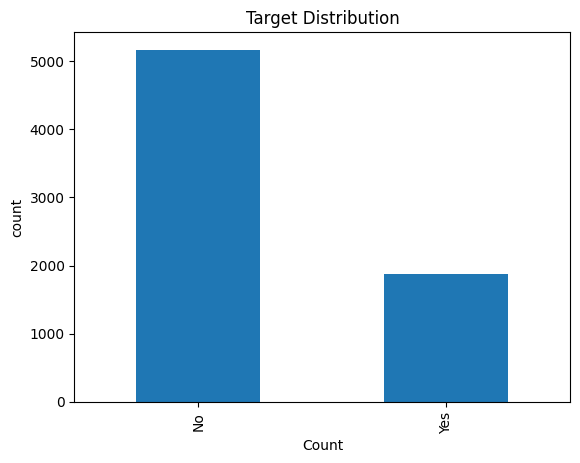

In [113]:
#Traget Distribution
df['Churn'].value_counts().plot(kind='bar')
plt.title("Target Distribution")
plt.xlabel("Count")
plt.ylabel("count")

In [114]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [115]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [116]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [117]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Text(0.5, 1.0, 'tenure Distribution in Churn groups')

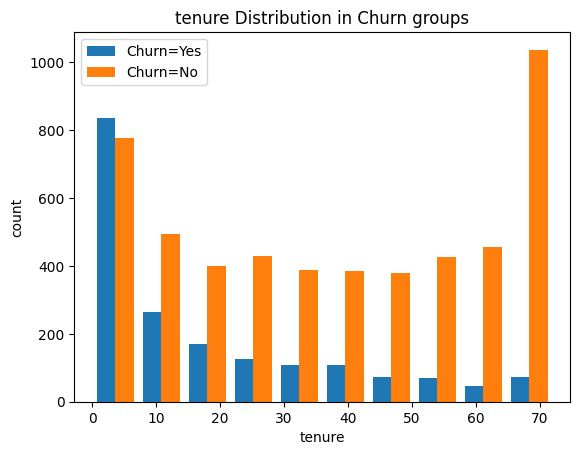

In [118]:
tenure_churn_no=df[df.Churn=='No'].tenure
tenure_churn_yes=df[df.Churn=='Yes'].tenure

plt.hist([tenure_churn_yes,tenure_churn_no])
plt.legend(['Churn=Yes','Churn=No'])
plt.xlabel('tenure')
plt.ylabel('count')
plt.title('tenure Distribution in Churn groups')

Text(0, 0.5, 'count')

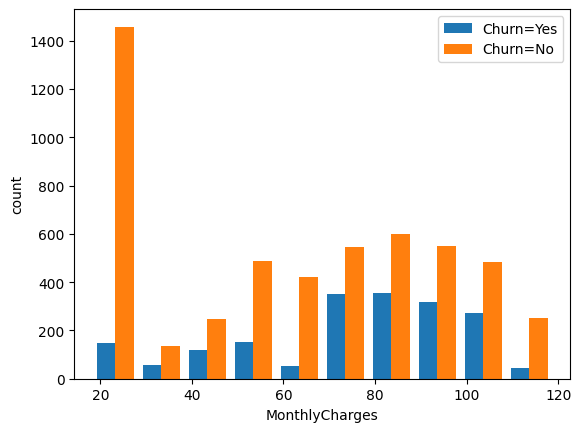

In [119]:
MonthlyCharges_churn_no=df[df.Churn=='No'].MonthlyCharges
MonthlyCharges_churn_yes=df[df.Churn=='Yes'].MonthlyCharges

plt.hist([MonthlyCharges_churn_yes,MonthlyCharges_churn_no])
plt.legend(['Churn=Yes','Churn=No'])
plt.xlabel('MonthlyCharges')
plt.ylabel('count')

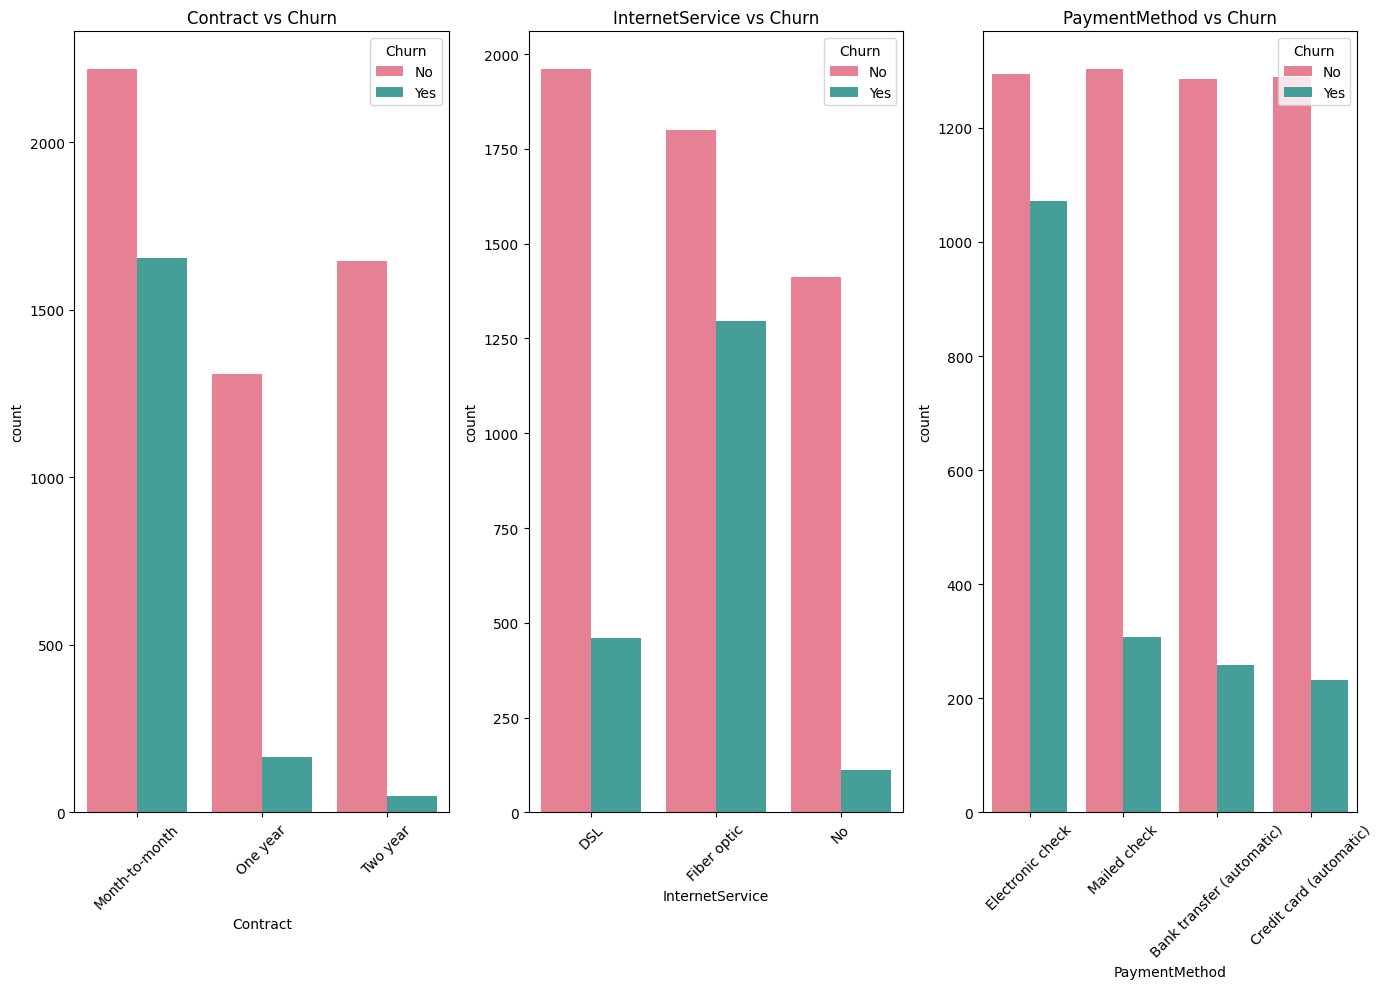

In [120]:
#Importanat categorical Features vs Churn
cat_cols = ['Contract', 'InternetService', 'PaymentMethod']

fig, axes = plt.subplots(1, 3, figsize=(14, 10))
axes = axes.ravel()
for i, col in enumerate(cat_cols):
    sns.countplot(data=df, x=col, hue='Churn', ax=axes[i], palette='husl')
    axes[i].set_title(f'{col} vs Churn')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

In [121]:
df_copy=df.copy()
df_copy[df_copy.TotalCharges.isnull()==True]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [122]:
#Impute missing TotalCharges
df_copy['TotalCharges']=df_copy['TotalCharges'].fillna(0)


In [123]:
df_copy.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


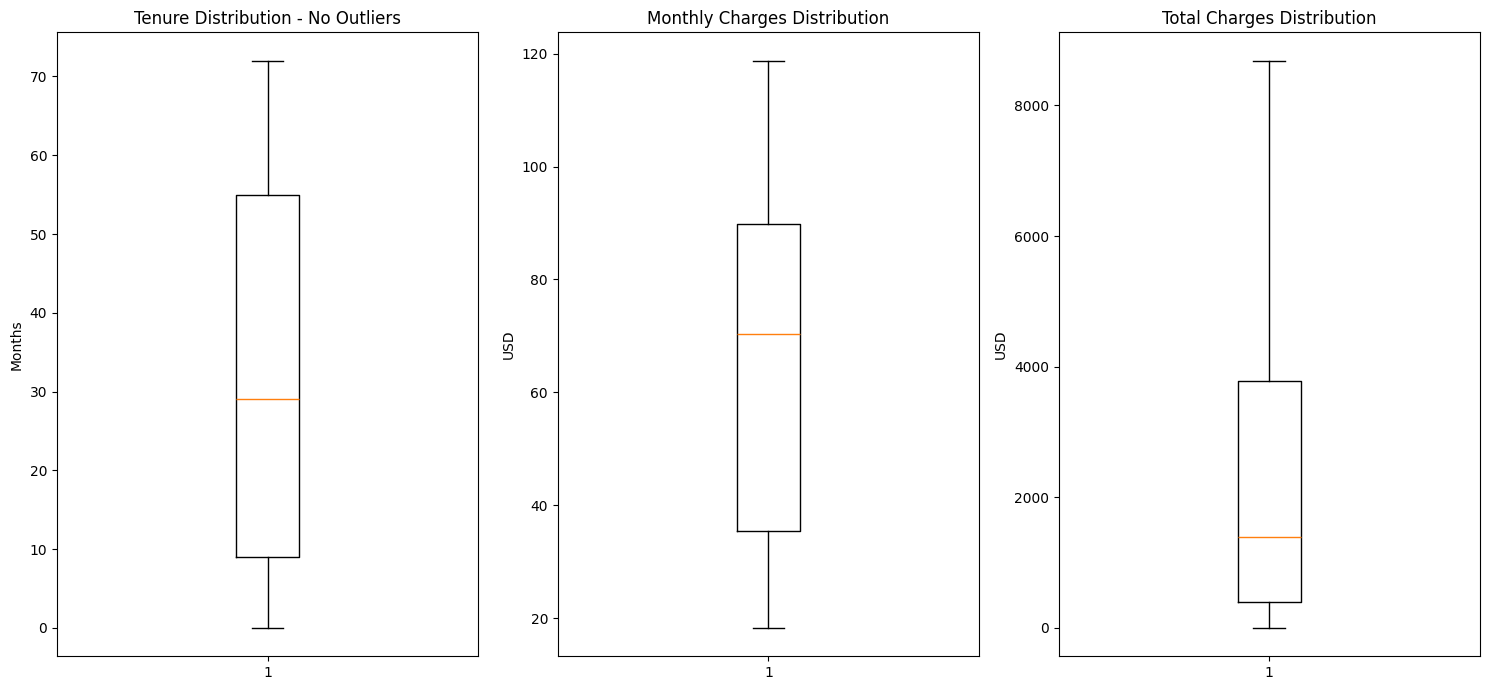

In [124]:
#detect outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 7))

# Tenure outliers
axes[0].boxplot(df_copy['tenure'])
axes[0].set_title('Tenure Distribution - No Outliers')
axes[0].set_ylabel('Months')

# Monthly Charges outliers
axes[1].boxplot(df_copy['MonthlyCharges'])
axes[1].set_title('Monthly Charges Distribution')
axes[1].set_ylabel('USD')

# Total Charges outliers
axes[2].boxplot(df_copy['TotalCharges'])
axes[2].set_title('Total Charges Distribution')
axes[2].set_ylabel('USD')

plt.tight_layout()
plt.show()

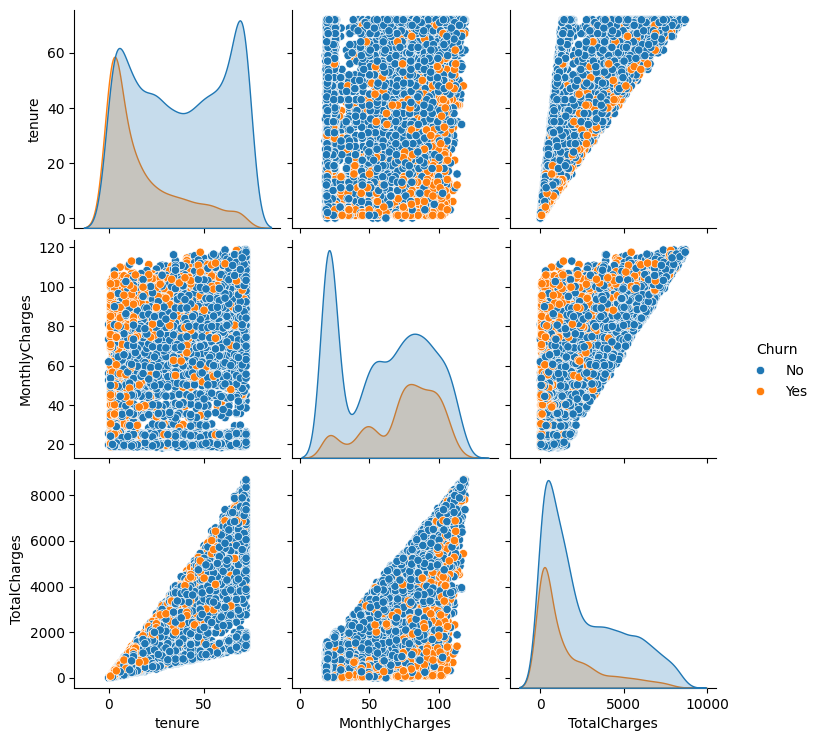

In [125]:
sns.pairplot(data=df_copy[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']],hue="Churn")

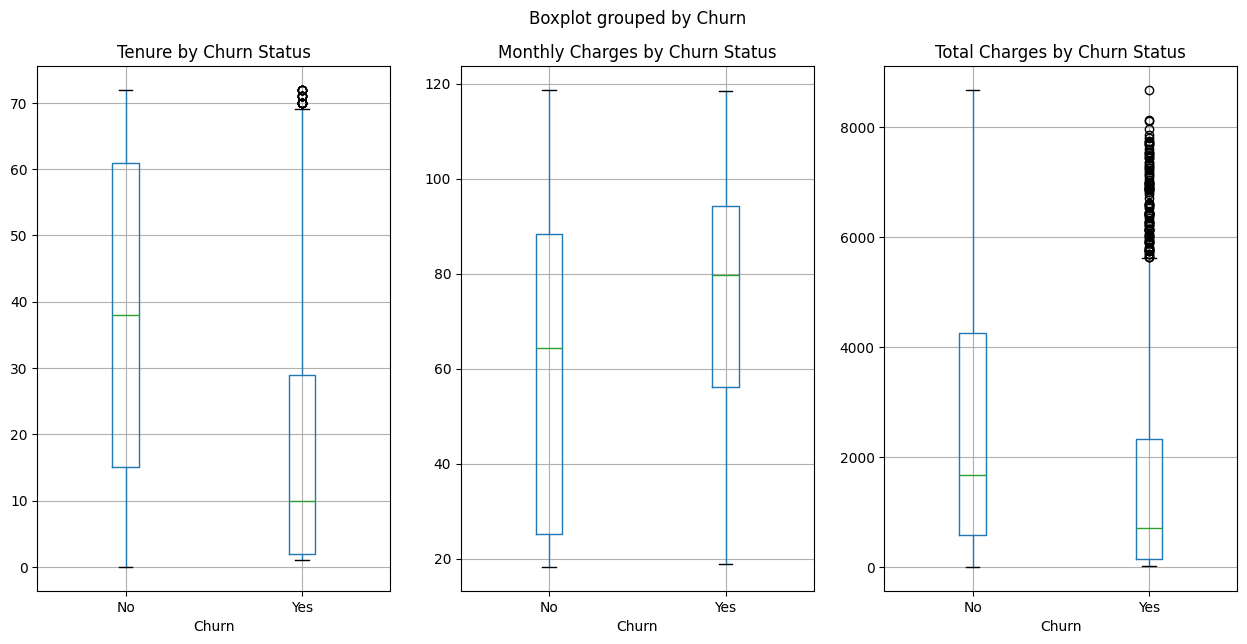

In [126]:
#Feature interactions with churn
fig, axes = plt.subplots(1, 3, figsize=(15, 7))

df_copy.boxplot(column='tenure', by='Churn', ax=axes[0])
axes[0].set_title('Tenure by Churn Status')

df_copy.boxplot(column='MonthlyCharges', by='Churn', ax=axes[1])
axes[1].set_title('Monthly Charges by Churn Status')

df_copy.boxplot(column='TotalCharges', by='Churn', ax=axes[2])
axes[2].set_title('Total Charges by Churn Status')

plt.show()

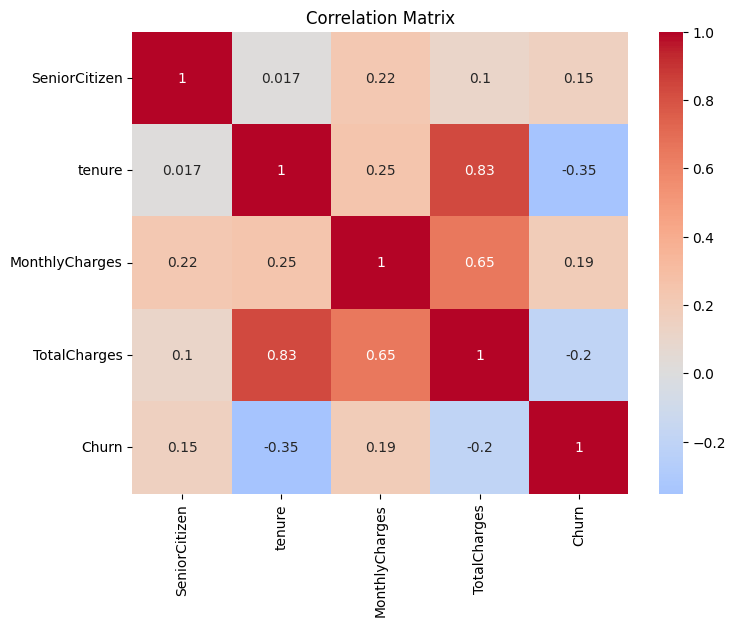

In [127]:
#Correlation Heatmap
df_corr = df_copy
df_corr['Churn'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

# Select numeric only
corr = df_corr.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

In [128]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [129]:
df_copy=df_copy.drop("customerID",axis=1)

In [130]:
df_copy.head().T

,0,1,2,3,4
gender,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0
Partner,Yes,No,No,No,No
Dependents,No,No,No,No,No
tenure,1,34,2,45,2
PhoneService,No,Yes,Yes,No,Yes
MultipleLines,No phone service,No,No,No phone service,No
InternetService,DSL,DSL,DSL,DSL,Fiber optic
OnlineSecurity,No,Yes,Yes,Yes,No
OnlineBackup,Yes,No,Yes,No,No


In [131]:
#Covert Yes/No columns to 1/0
for col in df_copy.columns:
  if set(df_copy[col].unique())==set(['Yes','No']):
    df_copy[col]=df_copy[col].map({'Yes':1,'No':0})

In [132]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   object 


In [133]:
#Convert Gender Column Male=1 Female=0
if 'gender' in df_copy.columns:
  df_copy['gender']=df_copy['gender'].map({'Male':1,'Female':0})

df_copy['gender'].dtypes

dtype('int64')

In [134]:
X=df_copy.drop('Churn',axis=1)
y=df_copy['Churn']

In [135]:
for col in df_copy.columns:
  if (df_copy[col].dtypes)=='object':
    print(col)

MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaymentMethod


In [136]:
#Split the data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

In [137]:
#For later experiments
X_raw_train=X_train.copy()
X_raw_test=X_test.copy()
y_raw_train=y_train.copy()
y_raw_test=y_test.copy()

In [138]:
#Scale the numerical data
numerical_features = ["tenure", "MonthlyCharges","TotalCharges"]
Scaler = StandardScaler()

X_train[numerical_features] = Scaler.fit_transform(X_train[numerical_features])
X_test[numerical_features] = Scaler.transform(X_test[numerical_features])


In [139]:
#One-hot encoder
categorical_features=['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod']
one_hot=OneHotEncoder()
transformer=ColumnTransformer([("one_hot",
                               one_hot,
                               categorical_features)],
                              remainder="passthrough")
X_train=transformer.fit_transform(X_train)
X_test=transformer.transform(X_test)

# **DecisionTreeClassifier**

In [140]:
#fit the model with weighted class (base model)
model_1=DecisionTreeClassifier(random_state=42,class_weight="balanced")
model_1.fit(X_train,y_train)


DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [141]:
model_1.score(X_test,y_test)

0.7174633222905821

### Hyperparameter Tuning with RandomizedSearchCV


In [142]:
rs_grid={
    "criterion":["gini", "entropy", "log_loss"],
    "max_depth":np.arange(1,10),
    "min_samples_split":np.arange(2,10),
    "min_samples_leaf":[1,2,4,5,7,8,10]

}

np.random.seed(42)
rs=RandomizedSearchCV(model_1,
                      param_distributions=rs_grid,
                      cv=5,
                      n_iter=30,
                      verbose=True)

rs.fit(X_train,y_train)
rs.best_params_

Fitting 5 folds for each of 30 candidates, totalling 150 fits


{'min_samples_split': np.int64(7),
 'min_samples_leaf': 10,
 'max_depth': np.int64(4),
 'criterion': 'log_loss'}

In [143]:
rs.score(X_test,y_test)

0.7486985328916232

### Hyperparameter Tuning with gridSearchCV

In [144]:
gs_grid={
    "criterion":["entropy", "log_loss"],
    "max_depth":[5],
    "min_samples_split":[5,6,7,9],
    "min_samples_leaf":[3,4,6,8]
}

np.random.seed(42)

gs=GridSearchCV(model_1,
                param_grid=gs_grid,
                cv=5,
                verbose=True)

gs.fit(X_train,y_train)
gs.best_params_

Fitting 5 folds for each of 32 candidates, totalling 160 fits


{'criterion': 'entropy',
 'max_depth': 5,
 'min_samples_leaf': 6,
 'min_samples_split': 5}

In [185]:
gs.score(X_train,y_train)

0.7330628803245436

In [145]:
gs.score(X_test,y_test)

0.7113109323237103

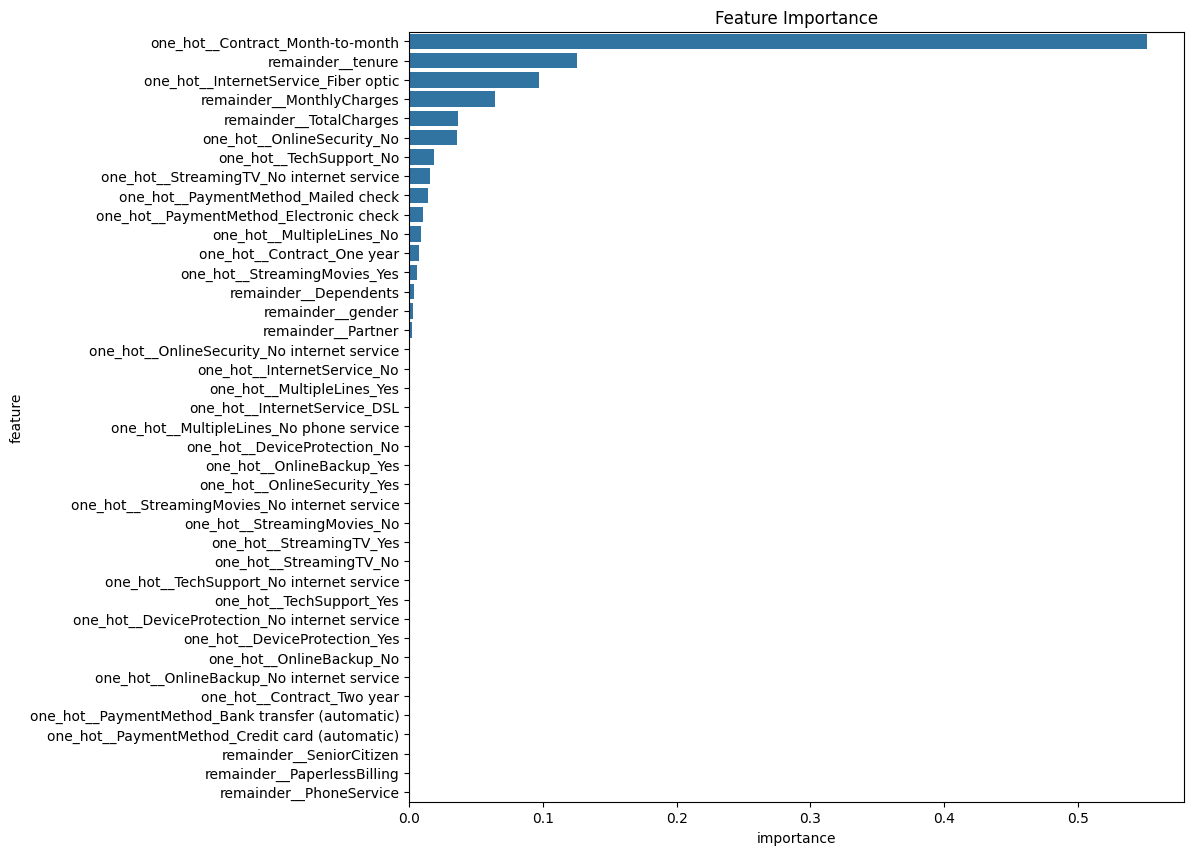

In [146]:
feature_importance = gs.best_estimator_.feature_importances_
feature_names = transformer.get_feature_names_out()

fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 10))
sns.barplot(data=fi_df, x='importance', y='feature')
plt.title('Feature Importance')
plt.show()

#### Save the model

In [147]:
#save
import pickle
pickle.dump(gs,open("best_churn_decision_tree_model.pkl","wb"))

### Evaluating Decision Tree

#### Evaluating base model

In [148]:
y_preds_weighted_dt=model_1.predict(X_test)

In [149]:
print(confusion_matrix(y_test,y_preds_weighted_dt))

[[1248  304]
 [ 293  268]]


In [150]:
print(classification_report(y_test,y_preds_weighted_dt))

              precision    recall  f1-score   support

           0       0.81      0.80      0.81      1552
           1       0.47      0.48      0.47       561

    accuracy                           0.72      2113
   macro avg       0.64      0.64      0.64      2113
weighted avg       0.72      0.72      0.72      2113



#### Evaluating tuned model

In [151]:
y_preds_tuned_dt=gs.predict(X_test)

In [152]:
dt_accuracy=accuracy_score(y_test,y_preds_tuned_dt)
print(f"Accuracy: {dt_accuracy}")

Accuracy: 0.7113109323237103


In [153]:
dt_precision=precision_score(y_test,y_preds_tuned_dt)
print(f"Precision: {dt_precision}")

Precision: 0.4740740740740741


In [154]:
dt_recall=recall_score(y_test,y_preds_tuned_dt)
print(f"Recall: {dt_recall}")

Recall: 0.7985739750445633


In [155]:
dt_f1=f1_score(y_test,y_preds_tuned_dt)
print(f"F1 Score: {dt_f1}")

F1 Score: 0.5949535192563081


In [156]:
y_probs_dt=gs.predict_proba(X_test)[:,1]

In [157]:
auc_dt=roc_auc_score(y_test,y_probs_dt)
print(f"AUC-ROC Score: {auc_dt}")

AUC-ROC Score: 0.8288643714280463


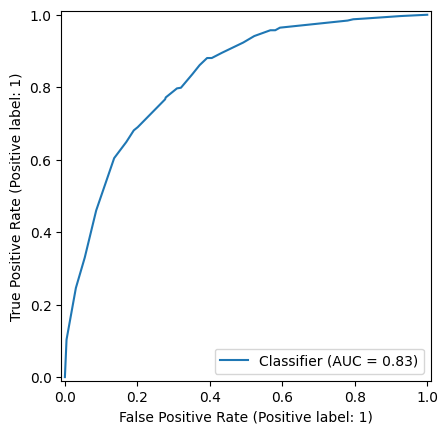

In [158]:
RocCurveDisplay.from_predictions(y_test,y_probs_dt)

In [159]:
print(confusion_matrix(y_test, y_preds_tuned_dt))

[[1055  497]
 [ 113  448]]


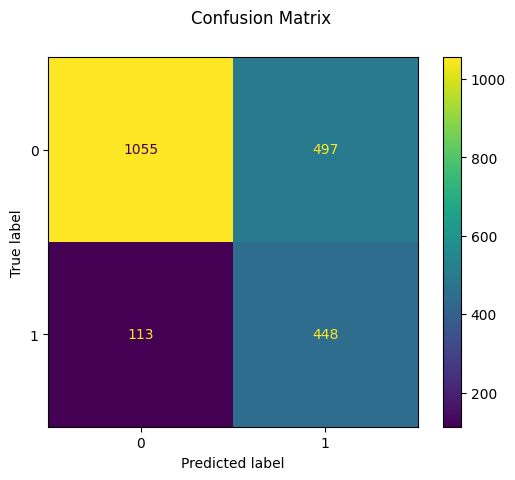

In [160]:
Confy_mat=ConfusionMatrixDisplay.from_predictions(y_test,y_preds_tuned_dt)
Confy_mat.figure_.suptitle("Confusion Matrix")
plt.show()

In [161]:
print(classification_report(y_test,y_preds_tuned_dt))

              precision    recall  f1-score   support

           0       0.90      0.68      0.78      1552
           1       0.47      0.80      0.59       561

    accuracy                           0.71      2113
   macro avg       0.69      0.74      0.69      2113
weighted avg       0.79      0.71      0.73      2113



### **Experiments**

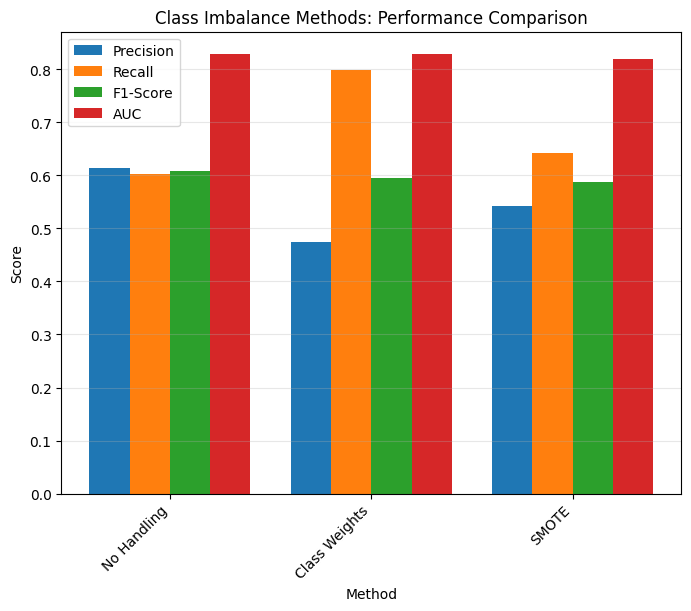

In [162]:
from imblearn.over_sampling import SMOTE

def evaluate_model(X_train_balanced, y_train_balanced, X_test, y_test, method_name):
    dt = DecisionTreeClassifier(**gs.best_params_, random_state=42)
    dt.fit(X_train_balanced, y_train_balanced)
    y_pred = dt.predict(X_test)

    return {
        'Method': method_name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC': roc_auc_score(y_test, dt.predict_proba(X_test)[:, 1])
    }

results = []

#No handling
dt_baseline = DecisionTreeClassifier(random_state=42)
dt_baseline.fit(X_train, y_train)
results.append(evaluate_model(X_train, y_train, X_test, y_test,"No Handling"))

#Weighted
y_dt=gs.predict(X_test)
weighted_dt_prob = gs.predict_proba(X_test)[:, 1]
results.append({
    'Method': 'Class Weights',
    'Accuracy': accuracy_score(y_test, y_dt),
    'Precision': precision_score(y_test,y_dt),
    'Recall': recall_score(y_test, y_dt),
    'F1-Score': f1_score(y_test, y_dt),
    'AUC': roc_auc_score(y_test, weighted_dt_prob)
})

#SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
results.append(evaluate_model(X_train_smote, y_train_smote, X_test, y_test,"SMOTE"))

results_df = pd.DataFrame(results)

plt.figure(figsize=(8, 6))

metrics = ['Precision', 'Recall', 'F1-Score', 'AUC']
x = np.arange(len(results_df))
width = 0.2

for i, metric in enumerate(metrics):
    plt.bar(x + i*width, results_df[metric], width, label=metric)

plt.xlabel('Method')
plt.ylabel('Score')
plt.title('Class Imbalance Methods: Performance Comparison')
plt.xticks(x + width * 1.5, results_df['Method'], rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

plt.show()

#**Neural Network**

In [163]:
import tensorflow as tf
import numpy as np
import random

random_set_seed = 42

random.seed(random_set_seed)
np.random.seed(random_set_seed)
tf.random.set_seed(random_set_seed)

In [164]:
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights = {0: class_weights[0], 1: class_weights[1]}

In [165]:
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

In [166]:
# Build the model
def build_model(input_shape):
    model = tf.keras.models.Sequential([
        tf.keras.layers.Input(shape=input_shape),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(32, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    return model


input_shape = (X_train.shape[1],)
model_2 = build_model(input_shape)

In [167]:
#compile the model
model_2.compile(optimizer='adam',
                loss='binary_crossentropy',
                metrics = ['accuracy',tf.keras.metrics.AUC(name='auc')])

In [168]:
#early stopping
early_stopping_main=tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=10,restore_best_weights=True)

#model Summary
model_2.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                │ (None, 64)             │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [169]:
X_train_final,X_val,y_train_final,y_val=train_test_split(X_train,y_train,test_size=0.2,random_state=42,stratify=y_train)

In [170]:
#train the model

history=model_2.fit(
    X_train_final,y_train_final,
    epochs=200,
    batch_size=32,
    class_weight=class_weights,
    validation_data=(X_val,y_val),
    callbacks=[early_stopping_main],
    verbose=1
)

Epoch 1/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.5900 - auc: 0.6218 - loss: 0.6716 - val_accuracy: 0.6937 - val_auc: 0.8010 - val_loss: 0.5579
Epoch 2/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7137 - auc: 0.7774 - loss: 0.5789 - val_accuracy: 0.6978 - val_auc: 0.8178 - val_loss: 0.5342
Epoch 3/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.7188 - auc: 0.7956 - loss: 0.5496 - val_accuracy: 0.7008 - val_auc: 0.8239 - val_loss: 0.5329
Epoch 4/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7322 - auc: 0.7982 - loss: 0.5517 - val_accuracy: 0.7160 - val_auc: 0.8264 - val_loss: 0.5159
Epoch 5/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7320 - auc: 0.8152 - loss: 0.5337 - val_accuracy: 0.7170 - val_auc: 0.8290 - val_loss: 0.5185
Epoch 6/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.7269 - auc: 0.8215 - loss: 0.5197 - val_accuracy: 0.7201 - val_auc: 0.8293 - val_loss: 0.5147
Epoch 7/200
124/124 ━━━━━━━━━

In [171]:
#Evaluate the model
loss,accuracy,auc=model_2.evaluate(X_test,y_test)
print("Test Loss: ",loss)
print("Test Accuracy: ",accuracy)
print("Test AUC: ",auc)

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7435 - auc: 0.8400 - loss: 0.4800
Test Loss:  0.4828873574733734
Test Accuracy:  0.7496450543403625
Test AUC:  0.8396123647689819


#### Hyperparameter Tuning

In [172]:
pip install -q keras-tuner

In [173]:
import shutil
shutil.rmtree("tuner_output", ignore_errors=True)

In [174]:
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

In [175]:
import keras_tuner as kt

def build_hyper_model(hp):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(X_train.shape[1],)))

    num_layers = hp.Int("num_layers", 1, 3)

    for i in range(num_layers):
        units = hp.Int(f"units_{i}", min_value=32, max_value=128, step=32)
        activation = hp.Choice(f"activation_{i}", ["relu", "swish"])

        model.add(tf.keras.layers.Dense(units, activation=activation))

        dropout = hp.Float(f"dropout_{i}", 0.2, 0.5, step=0.1)
        model.add(tf.keras.layers.Dropout(dropout))

    model.add(tf.keras.layers.Dense(1, activation="sigmoid"))

    lr = hp.Choice("learning_rate", [1e-3, 5e-4, 1e-4])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=['accuracy',tf.keras.metrics.AUC(name="auc")]
    )

    return model

In [176]:
tuner=kt.Hyperband(build_hyper_model,
                   objective='val_auc',
                   max_epochs=20,
                   factor=3,
                   seed=42,
                   directory='tuner_output',
                   project_name='nn_tuning_telco')

In [177]:
early_stopping=tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)


In [178]:
tuner.search(X_train_final,y_train_final,validation_data=(X_val,y_val),callbacks=[early_stopping],class_weight=class_weights)

Trial 30 Complete [00h 00m 14s]
val_auc: 0.8370403051376343

Best val_auc So Far: 0.8396340608596802
Total elapsed time: 00h 04m 06s


In [182]:
best_hps=tuner.get_best_hyperparameters()[0]
best_hps.values

{'num_layers': 2,
 'units_0': 96,
 'activation_0': 'swish',
 'dropout_0': 0.4,
 'learning_rate': 0.001,
 'units_1': 128,
 'activation_1': 'swish',
 'dropout_1': 0.30000000000000004,
 'units_2': 128,
 'activation_2': 'swish',
 'dropout_2': 0.2,
 'tuner/epochs': 20,
 'tuner/initial_epoch': 0,
 'tuner/bracket': 0,
 'tuner/round': 0}

In [ ]:
tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()
model_2_tuned=tuner.hypermodel.build(best_hps)
tuned_history=model_2_tuned.fit(
    X_train_final,y_train_final,
    epochs=200,
    batch_size=32,
    class_weight=class_weights,
    validation_data=(X_val,y_val),
    callbacks=[early_stopping_main],
    verbose=1
)

Epoch 1/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.6731 - auc: 0.7647 - loss: 0.5792 - val_accuracy: 0.7018 - val_auc: 0.8340 - val_loss: 0.5383
Epoch 2/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7339 - auc: 0.8268 - loss: 0.5111 - val_accuracy: 0.7211 - val_auc: 0.8360 - val_loss: 0.5174
Epoch 3/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7247 - auc: 0.8211 - loss: 0.5136 - val_accuracy: 0.7170 - val_auc: 0.8361 - val_loss: 0.5190
Epoch 4/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7337 - auc: 0.8247 - loss: 0.5138 - val_accuracy: 0.7221 - val_auc: 0.8370 - val_loss: 0.5211
Epoch 5/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7308 - auc: 0.8299 - loss: 0.5048 - val_accuracy: 0.7211 - val_auc: 0.8361 - val_loss: 0.5124
Epoch 6/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7324 - auc: 0.8309 - loss: 0.5054 - val_accuracy: 0.7231 - val_auc: 0.8366 - val_loss: 0.5148
Epoch 7/200
124/124 ━━━━━━━━━━━━━

In [ ]:
#Evaluate the model
loss,accuracy,auc=model_2_tuned.evaluate(X_test,y_test)
print("Test Loss: ",loss)
print("Test Accuracy: ",accuracy)
print("Test AUC: ",auc)

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7379 - auc: 0.8383 - loss: 0.4933
Test Loss:  0.49225735664367676
Test Accuracy:  0.7444391846656799
Test AUC:  0.8406747579574585


#### Save the model

In [ ]:
model_2_tuned.save("best_churn_NN_model.keras")

## Evaluating Neural Netwoek

#### Evaluating base NN

In [ ]:
y_preds_prob_base=model_2.predict(X_test)

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
y_preds_base=(y_preds_prob_base>0.5).astype(int)

In [ ]:
print(confusion_matrix(y_test,y_preds_base))

[[1155  397]
 [ 132  429]]


In [ ]:
print(classification_report(y_test,y_preds_base))

              precision    recall  f1-score   support

           0       0.90      0.74      0.81      1552
           1       0.52      0.76      0.62       561

    accuracy                           0.75      2113
   macro avg       0.71      0.75      0.72      2113
weighted avg       0.80      0.75      0.76      2113



#### Evaluating tuned NN

In [ ]:
y_preds_prob=model_2_tuned.predict(X_test)

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [ ]:
y_preds_prob

array([[0.80774075],
       [0.01808056],
       [0.91806924],
       ...,
       [0.12433755],
       [0.7949486 ],
       [0.06540506]], dtype=float32)

In [ ]:
y_preds=(y_preds_prob>0.5).astype(int)

In [ ]:
nn_accuracy=accuracy_score(y_test,y_preds)
print(f"Accuracy: {nn_accuracy}")

Accuracy: 0.7444391859914813


In [ ]:
nn_precision=precision_score(y_test,y_preds)
print(f"Precision: {nn_precision}")

Precision: 0.5122235157159488


In [ ]:
nn_recall=recall_score(y_test,y_preds)
print(f"Recall: {nn_recall}")

Recall: 0.7843137254901961


In [ ]:
nn_f1=f1_score(y_test,y_preds)
print(f"F1 Score: {nn_f1}")

F1 Score: 0.6197183098591549


In [ ]:
print(classification_report(y_test,y_preds))

              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1552
           1       0.51      0.78      0.62       561

    accuracy                           0.74      2113
   macro avg       0.71      0.76      0.71      2113
weighted avg       0.80      0.74      0.76      2113



In [ ]:
print(confusion_matrix(y_test,y_preds))

[[1133  419]
 [ 121  440]]


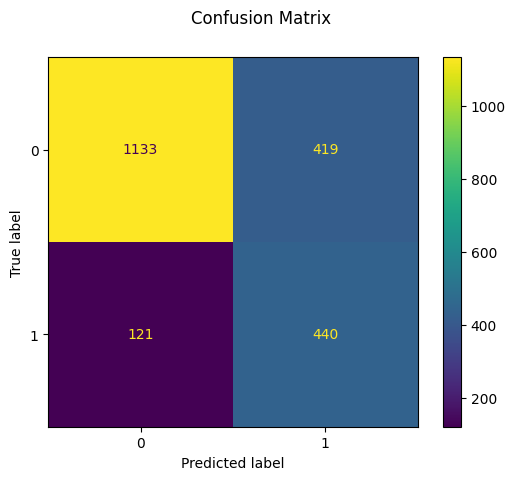

In [ ]:
Confy_mat=ConfusionMatrixDisplay.from_predictions(y_test,y_preds)
Confy_mat.figure_.suptitle("Confusion Matrix")
plt.show()

In [ ]:
auc_nn=roc_auc_score(y_test,y_preds_prob)
print(f"AUC-ROC Score: {auc_nn}")

AUC-ROC Score: 0.8407006312365622


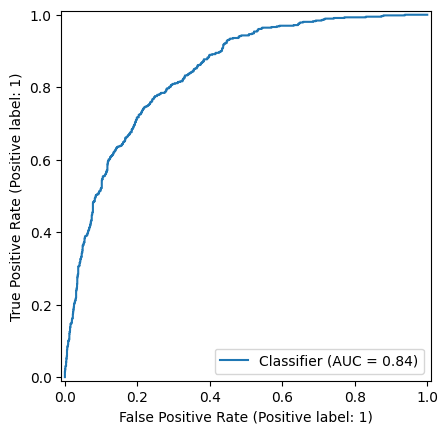

In [ ]:
RocCurveDisplay.from_predictions(y_test,y_preds_prob)

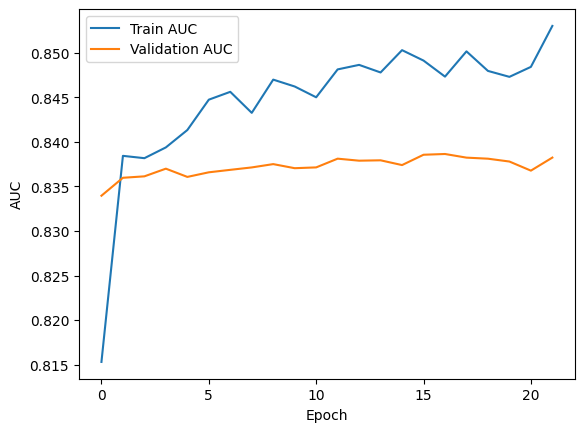

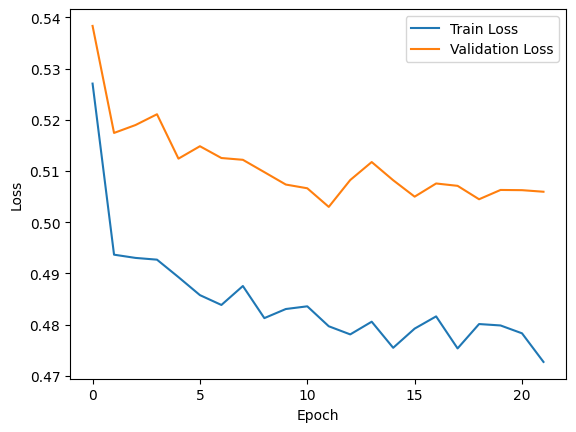

In [ ]:
# AUC
plt.plot(tuned_history.history['auc'], label='Train AUC')
plt.plot(tuned_history.history['val_auc'], label='Validation AUC')
plt.xlabel('Epoch')
plt.ylabel('AUC')
plt.legend()
plt.show()

# Loss
plt.plot(tuned_history.history['loss'], label='Train Loss')
plt.plot(tuned_history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

### **Experiment**

In [ ]:
def build_tuned_nn_model(input_shape, best_hps):
    model = tf.keras.models.Sequential()
    model.add(tf.keras.layers.Input(shape=input_shape))

    num_layers = best_hps.values['num_layers']

    for i in range(num_layers):
        units = best_hps.values[f'units_{i}']
        activation = best_hps.values[f'activation_{i}']
        model.add(tf.keras.layers.Dense(units, activation=activation))

        dropout_rate = best_hps.values[f'dropout_{i}']
        model.add(tf.keras.layers.Dropout(dropout_rate))

    model.add(tf.keras.layers.Dense(1, activation='sigmoid'))

    learning_rate = best_hps.values['learning_rate']
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

def train_evaluate_tuned_nn(X_train_data, y_train_data, X_test_data, y_test_data,
                            X_val_data, y_val_data, input_shape, best_hps,
                            method_name, class_weights_dict):

    tf.keras.utils.set_random_seed(42)
    tf.config.experimental.enable_op_determinism()
    model = build_tuned_nn_model(input_shape, best_hps)

    history = model.fit(
        X_train_data, y_train_data,
        epochs=200,
        batch_size=32,
        class_weight=class_weights_dict,
        validation_data=(X_val_data, y_val_data),
        callbacks=[early_stopping_main],
        verbose=1
    )

    loss, accuracy = model.evaluate(X_test_data, y_test_data)

    y_pred_prob = model.predict(X_test_data)
    y_pred = (y_pred_prob >= 0.5).astype(int)

    metrics = {
        'Method': method_name,
        'Test Loss': loss,
        'Accuracy': accuracy_score(y_test_data, y_pred),
        'Precision': precision_score(y_test_data, y_pred),
        'Recall': recall_score(y_test_data, y_pred),
        'F1-Score': f1_score(y_test_data, y_pred),
        'AUC': roc_auc_score(y_test_data, y_pred_prob),
    }

    return metrics, model, history, y_pred, y_pred_prob

In [ ]:
X_train_ns_df = X_raw_train.copy()
y_train_ns_series = y_raw_train.copy()
X_test_ns_df = X_raw_test.copy()
y_test_ns_series = y_raw_test.copy()

categorical_features=['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod']
one_hot=OneHotEncoder(handle_unknown='ignore')

transformer_noscale = ColumnTransformer([
    ("one_hot",
     one_hot,
     categorical_features)
], remainder="passthrough")

X_train_transformed_ns = transformer_noscale.fit_transform(X_train_ns_df)
X_test_ns_transformed = transformer_noscale.transform(X_test_ns_df)

X_train_final_ns, X_val_ns, y_train_final_ns, y_val_ns = train_test_split(X_train_transformed_ns, y_train_ns_series, test_size=0.2, random_state=42, stratify=y_train_ns_series)

exp_ns_metrics, exp_ns_model, exp_ns_hist, exp_ns_pred, exp_ns_pred_prob = \
    train_evaluate_tuned_nn(
        X_train_final_ns, y_train_final_ns,
        X_test_ns_transformed, y_test_ns_series,
        X_val_ns, y_val_ns,
        X_train_transformed_ns.shape[1:], best_hps,
        "NN Experiment – No Scaling", class_weights
)

Epoch 1/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5925 - loss: 50.6104 - val_accuracy: 0.2667 - val_loss: 6.6433
Epoch 2/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5696 - loss: 23.9256 - val_accuracy: 0.2667 - val_loss: 5.4006
Epoch 3/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5686 - loss: 11.5046 - val_accuracy: 0.6917 - val_loss: 0.5928
Epoch 4/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5609 - loss: 5.4705 - val_accuracy: 0.7181 - val_loss: 0.5734
Epoch 5/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6122 - loss: 2.4279 - val_accuracy: 0.5609 - val_loss: 0.6666
Epoch 6/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5650 - loss: 1.4728 - val_accuracy: 0.4533 - val_loss: 0.6894
Epoch 7/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5589 - loss: 1.1419 - val_accuracy: 0.2657 - val_loss: 0.7023
Epoch 8/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5682 - loss: 0.8940 - val_a

In [ ]:
from sklearn.preprocessing import MinMaxScaler

X_train_mm_df = X_raw_train.copy()
y_train_mm_series = y_raw_train.copy()
X_test_mm_df = X_raw_test.copy()
y_test_mm_series = y_raw_test.copy()

numerical_features_mm = ["tenure", "MonthlyCharges","TotalCharges"]
categorical_features_mm = ['MultipleLines','InternetService','OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','Contract','PaymentMethod']

preprocessor_minmax = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), numerical_features_mm),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features_mm)
    ],
    remainder='passthrough'
)


X_train_transformed_mm = preprocessor_minmax.fit_transform(X_train_mm_df)
X_test_mm_transformed = preprocessor_minmax.transform(X_test_mm_df)

X_train_final_mm, X_val_mm, y_train_final_mm, y_val_mm = train_test_split(X_train_transformed_mm, y_train_mm_series, test_size=0.2, random_state=42, stratify=y_train_mm_series)

exp_mm_metrics, exp_mm_model, exp_mm_hist, exp_mm_pred, exp_mm_pred_prob = \
    train_evaluate_tuned_nn(
        X_train_final_mm, y_train_final_mm,
        X_test_mm_transformed, y_test_mm_series,
        X_val_mm, y_val_mm,
        X_train_transformed_mm.shape[1:], best_hps,
        "NN Experiment – MinMax Scaling", class_weights
)


Epoch 1/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6615 - loss: 0.5883 - val_accuracy: 0.7059 - val_loss: 0.5370
Epoch 2/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7290 - loss: 0.5222 - val_accuracy: 0.7089 - val_loss: 0.5298
Epoch 3/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7319 - loss: 0.5117 - val_accuracy: 0.7150 - val_loss: 0.5282
Epoch 4/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7288 - loss: 0.5120 - val_accuracy: 0.7099 - val_loss: 0.5346
Epoch 5/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7266 - loss: 0.5130 - val_accuracy: 0.7211 - val_loss: 0.5226
Epoch 6/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7248 - loss: 0.5094 - val_accuracy: 0.7130 - val_loss: 0.5309
Epoch 7/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7346 - loss: 0.5078 - val_accuracy: 0.7262 - val_loss: 0.5204
Epoch 8/200
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7369 - loss: 0.5062 - val_accu

In [ ]:
comparison_df = pd.DataFrame([
    exp_ns_metrics,
    exp_mm_metrics
])[['Method','Accuracy','Precision','Recall','F1-Score','AUC']]

comparison_df


,Method,Accuracy,Precision,Recall,F1-Score,AUC
0,NN Experiment – No Scaling,0.733081,0.497453,0.522282,0.509565,0.716346
1,NN Experiment – MinMax Scaling,0.750592,0.520384,0.773619,0.622222,0.839318


In [ ]:
#Optimizing threshold
for threshold in [0.3, 0.35, 0.4, 0.45, 0.5]:
    y_pred = (y_preds_prob >= threshold).astype(int)
    recall = recall_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    print(f"Threshold {threshold}: Recall={recall:.3f}, Precision={precision:.3f}")

Threshold 0.3: Recall=0.895, Precision=0.434
Threshold 0.35: Recall=0.863, Precision=0.454
Threshold 0.4: Recall=0.832, Precision=0.473
Threshold 0.45: Recall=0.811, Precision=0.490
Threshold 0.5: Recall=0.784, Precision=0.512


In [184]:
# Use optimal threshold
optimal_threshold = 0.45
y_pred_optimal = (y_preds_prob >= optimal_threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_optimal)
print("NEURAL NETWORK WITH OPTIMIZED THRESHOLD (0.35)")
print(f"Confusion Matrix:\n{cm}")
print(f"\n{classification_report(y_test, y_pred_optimal)}")


NEURAL NETWORK WITH OPTIMIZED THRESHOLD (0.35)
Confusion Matrix:
[[1079  473]
 [ 106  455]]

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1552
           1       0.49      0.81      0.61       561

    accuracy                           0.73      2113
   macro avg       0.70      0.75      0.70      2113
weighted avg       0.80      0.73      0.74      2113



## **Demographic Bias**

In [ ]:
from tensorflow.keras.models import load_model
import pickle

model_nn = load_model("best_churn_NN_model.keras")

model_dt=pickle.load(open("best_churn_decision_tree_model.pkl","rb"))

In [ ]:
gender_idx = np.where(feature_names == 'remainder__gender')[0][0]

male_data = X_test[X_test[:, gender_idx] == 1]
male_target = y_test[X_test[:, gender_idx] == 1]

female_data = X_test[X_test[:, gender_idx] == 0]
female_target = y_test[X_test[:, gender_idx] == 0]

y_preds_male_dt = model_dt.predict(male_data)
y_preds_female_dt = model_dt.predict(female_data)

y_pred_male_nn_prob = model_nn.predict(male_data)
y_pred_female_nn_prob = model_nn.predict(female_data)

y_preds_male_nn = (y_pred_male_nn_prob >= 0.5).astype(int)
y_preds_female_nn = (y_pred_female_nn_prob >= 0.5).astype(int)

print("\nDecision Tree Model Metrics (Gender):")
print(f"Male - Precision: {precision_score(male_target,y_preds_male_dt)}, Recall: {recall_score(male_target,y_preds_male_dt)}")
print(f"Female - Precision: {precision_score(female_target,y_preds_female_dt):.3f}, Recall: {recall_score(female_target,y_preds_female_dt):.3f}")

print("\nNeural Network Model Metrics (Gender, with optimal threshold 0.5):")
print(f"Male - Precision: {precision_score(male_target,y_preds_male_nn)}, Recall: {recall_score(male_target,y_preds_male_nn)}")
print(f"Female - Precision: {precision_score(female_target,y_preds_female_nn)}, Recall: {recall_score(female_target,y_preds_female_nn)}")

34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

Decision Tree Model Metrics (Gender):
Male - Precision: 0.4684095860566449, Recall: 0.8052434456928839
Female - Precision: 0.479, Recall: 0.793

Neural Network Model Metrics (Gender, with optimal threshold 0.5):
Male - Precision: 0.4988399071925754, Recall: 0.8052434456928839
Female - Precision: 0.5257009345794392, Recall: 0.7653061224489796
